Fetching individual images via streamed remote zipfile...
[SUCCESS] Downloaded: OzBKmWt9zWo_frame_8071_0_0.jpg to derm_train_images/youtube/OzBKmWt9zWo_frame_8071_0_0.jpg


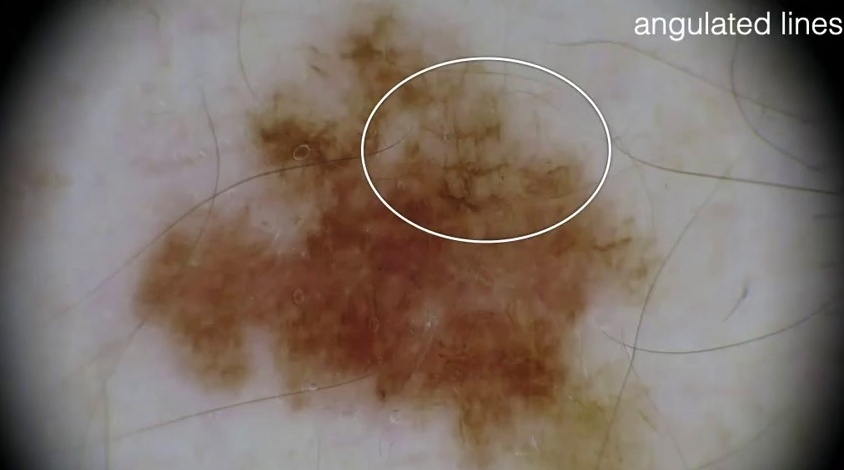

In [17]:
import io
import os
import zipfile
from PIL import Image
from huggingface_hub import HfFileSystem

# Initialize the file system 
fs = HfFileSystem()

pubmed_filenames = [
    "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    "00_39_PMC10381143_jimaging-09-00148-g012_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png"
]

IYII_filenames = [
    "2281_1.png"
]

youtube_filenames = [
    "OzBKmWt9zWo_frame_8071_0_0.jpg"
]

repo_id = "datasets/redlessone/Derm1M"
downloaded_images = {}

print("Fetching individual images via streamed remote zipfile...")

download_tasks = {
    # "pubmed": pubmed_filenames,
    # "IIYI": IYII_filenames,
    "youtube": youtube_filenames
}

for category, filenames in download_tasks.items():
    zip_name = f"{category}.zip"
    remote_zip_path = f"{repo_id}/{zip_name}"
    
    try:
        with fs.open(remote_zip_path, "rb") as remote_file:
            with zipfile.ZipFile(remote_file) as zf:
                
                for filename in filenames:
                    internal_path = f"{filename}"
                    
                    try:
                        with zf.open(internal_path) as img_file:
                            img = Image.open(io.BytesIO(img_file.read())).convert("RGB")
                            
                            downloaded_images[filename] = img
                            
                            local_save_path = f"derm_train_images/{category}/{filename}"
                            os.makedirs(os.path.dirname(local_save_path), exist_ok=True)
                            img.save(local_save_path)
                            
                            print(f"[SUCCESS] Downloaded: {filename} to {local_save_path}")
                            
                    except KeyError:
                        print(f"[ERROR] File '{internal_path}' does not exist inside '{zip_name}'.")
                    except Exception as e:
                        print(f"[ERROR] Failed to download {internal_path}: {e}")
                        
    except Exception as e:
        print(f"[ERROR] Could not open remote zip '{remote_zip_path}': {e}")

if downloaded_images:
    first_image = list(downloaded_images.values())[0]
    display(first_image)

In [14]:
!curl -o "metadata.csv" "https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/de867406-1a86-4eb7-bffa-3db4ab357f3f"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0  308k    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  308k  100  308k    0     0   500k      0 --:--:-- --:--:-- --:--:--  502k


In [ ]:
import pandas as pd
import os


df = pd.read_csv("metadata.csv")
directory = "pad_images"

img_names = []

for img_name in os.listdir(directory):
    img_names.append(img_name)
    # filepath = os.path.join(directory, img_name)

chosen = df[df["img_id"].isin(img_names)]
chosen["filename"] = chosen["img_id"]

skin_lesions = {
    "BCC": "Basal Cell Carcinoma",
    "SCC": "Squamous Cell Carcinoma",
    "ACK": "Actinic Keratosis",
    "SEK": "Seborrheic Keratosis",
    "MEL": "Melanoma",
    "NEV": "Nevus"
}
labels = list(skin_lesions.values()) # WAZNE
chosen["label"] = chosen["diagnostic"].map(skin_lesions)
chosen = chosen[["filename", "label"]]
chosen.to_csv("pad_images/meta.csv", index=False) 
print(chosen)
os.remove("metadata.csv")
# interesuje nas "label" i "filename" z meta.csv

                 filename                 label
234   PAT_15_1001_749.png  Basal Cell Carcinoma
271    PAT_79_120_739.png  Basal Cell Carcinoma
805    PAT_68_105_871.png  Basal Cell Carcinoma
855     PAT_50_76_296.png  Basal Cell Carcinoma
1007    PAT_29_40_561.png                 Nevus
